## Synch - Kuramoto order parameter (Lorenz)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.animation import FuncAnimation
%matplotlib inline
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.io import loadmat
import scipy.io as sio
from scipy.signal import hilbert
import os
from os.path import isfile,isdir,join
from os import listdir

### Data generation

In [2]:
"""
Lorenz, Edward Norton (1963). "Deterministic nonperiodic flow". Journal of the Atmospheric Sciences. 20 (2): 130–141.
https://doi.org/10.1175/1520-0469(1963)020<0130:DNF>2.0.CO;2

dx/dt = a(y -x)
dy/dt = x(b - z) - y
dz/dt = xy - cz
"""




def get_data(var, a = 10.0, b = 28.0, c = 8.0 / 3.0, dt = 0.01,
                  initial_values = [0.1, 0, 0], iterations=1000):
    """
        Get a simple univariate time series data.

        :param var: the dataset field name to extract
        :return: numpy array
        """
    return get_dataframe(a, b, c, dt, initial_values, iterations)[var].values



def get_dataframe(a = 10.0, b = 28.0, c = 8.0 / 3.0, dt = 0.01,
                  initial_values = [0.1, 0, 0], iterations=1000):
    '''
    Return a dataframe with the multivariate Lorenz Map time series (x, y, z).

    :param a: Equation coefficient. Default value: 10
    :param b: Equation coefficient. Default value: 28
    :param c: Equation coefficient. Default value: 8.0/3.0
    :param dt: Time differential for continuous time integration. Default value: 0.01
    :param initial_values: numpy array with the initial values of x,y and z. Default: [0.1, 0, 0]
    :param iterations: number of iterations. Default: 1000
    :return: Panda dataframe with the x, y and z values
    '''

    x = [initial_values[0]]
    y = [initial_values[1]]
    z = [initial_values[2]]

    for t in np.arange(0, iterations):
        dxdt = a * (y[t] - x[t])
        dydt = x[t] * (b - z[t]) - y[t]
        dzdt = x[t] * y[t] - c * z[t]
        x.append(x[t] + dt * dxdt)
        y.append(y[t] + dt * dydt)
        z.append(z[t] + dt * dzdt)

    return pd.DataFrame({'x': x, 'y':y, 'z': z})

In [3]:
df1 = get_dataframe(a = 10.0, b = 28.0, c = 8.0 / 3.0, dt = 0.01, initial_values = [0.01, 0, 0.3], iterations=1000)

In [4]:
df2 = get_dataframe(a = 10.0, b = 28.0, c = 8.0 / 3.0, dt = 0.01, initial_values = [0.2, 0.1, 0.4], iterations=1000)

In [5]:
#df = pd.read_parquet ('data/datos.pqt')

In [6]:
df1.shape

(1001, 3)

In [7]:
df2.shape

(1001, 3)

In [8]:
pd.options.display.float_format = '{:.8g}'.format

In [9]:
df1.describe()

,x,y,z
count,1001,1001,1001
mean,-2.1613707,-2.2557932,23.600001
std,7.8597001,9.2395187,10.40912
min,-14.991539,-18.18433,0.10875784
25%,-8.1685687,-8.8317417,17.196417
50%,-3.5117187,-3.6698617,24.691756
75%,1.6626302,2.0286851,29.82149
max,21.499835,29.431169,54.230903


In [10]:
df2.describe()

,x,y,z
count,1001,1001,1001
mean,0.31684051,0.42085653,23.634413
std,8.0525613,9.3172289,9.849874
min,-17.946231,-23.134911,0.28833555
25%,-5.7033699,-6.2613652,17.917185
50%,0.25437067,0.5205568,24.143064
75%,6.8559947,7.202176,30.170693
max,21.449666,29.289194,54.141031


In [11]:
varA = df1['x'].rolling(1).mean()
varA = varA.values

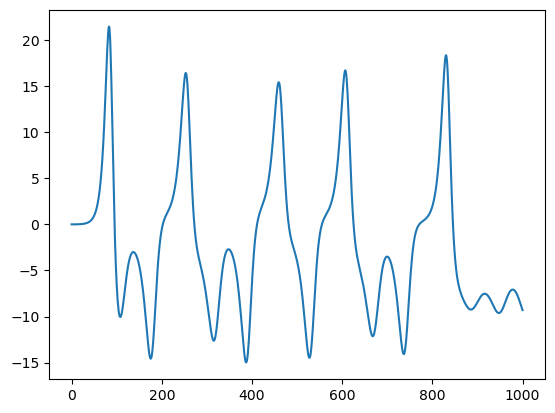

In [12]:
plt.plot(varA)

In [13]:
varB = df2['x'].rolling(1).mean()
varB = varB.values

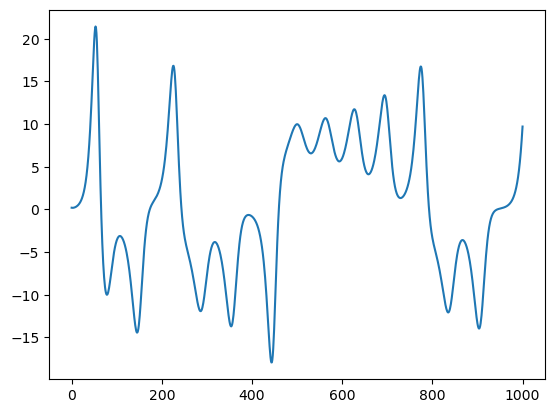

In [14]:
plt.plot(varB)

### Hilbert transforms

Analytic signal:
$\zeta(t)=s(t)+i s_H(t)=A e^{i\phi(t)}$,

where:
- $A(t)$: instantaneous amplitude of the signal $s(t)$
- $\phi(t)$: instantaneous phase of the signal $s(t)$
- $s_H(t)=\frac{1}{\pi} P.V. \int_{-\infty}^{\infty} \frac{s(\tau)}{t-\tau} d\tau$: Hilbert transform of the signal $s(t)$

In [15]:
hil_evol_A = hilbert(varA)

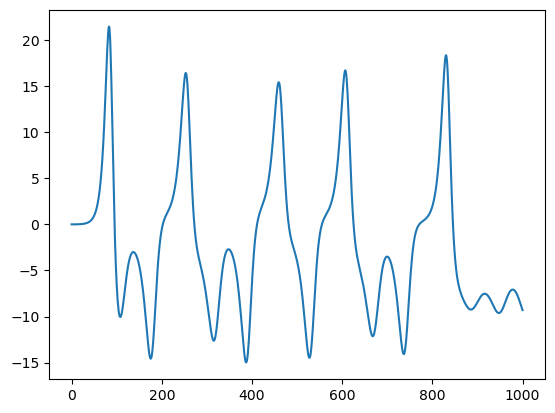

In [16]:
plt.plot(hil_evol_A.real)

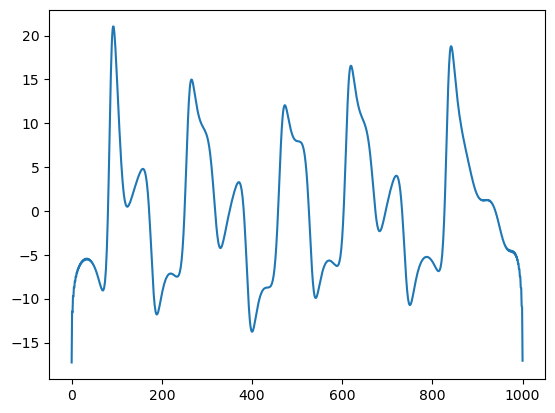

In [17]:
plt.plot(hil_evol_A.imag)

In [18]:
hil_evol_B = hilbert(varB)

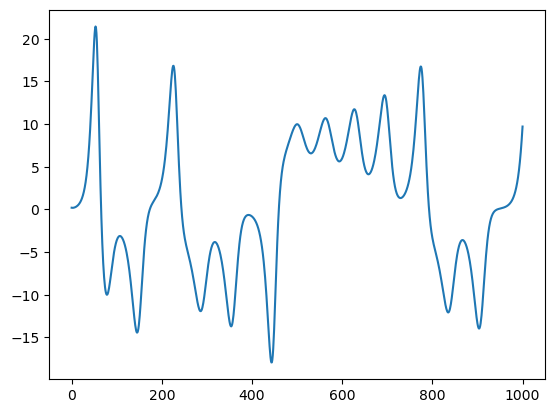

In [19]:
plt.plot(hil_evol_B.real)

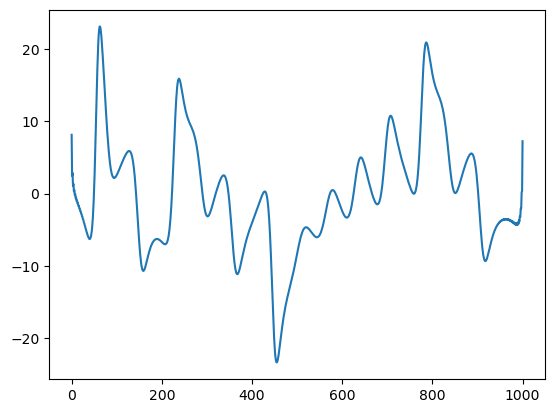

In [20]:
plt.plot(hil_evol_B.imag)

### Phases

In [21]:
ph_evol_A = np.arctan2(hil_evol_A.imag, hil_evol_A.real)

In [22]:
ph_evol_B = np.arctan2(hil_evol_B.imag, hil_evol_B.real)

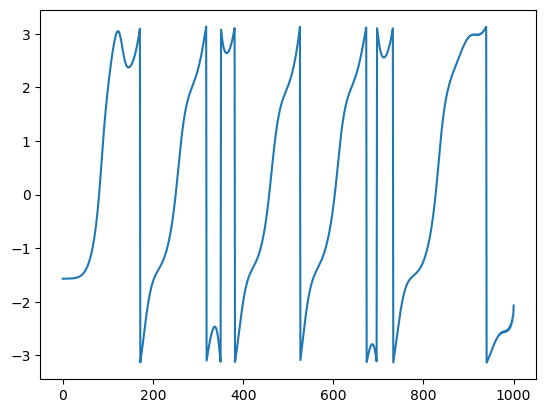

In [23]:
plt.plot(ph_evol_A)

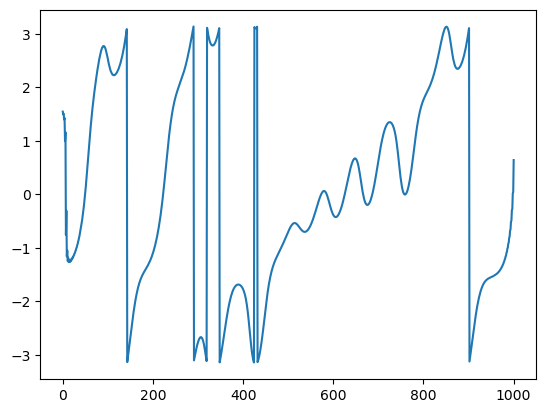

In [24]:
plt.plot(ph_evol_B)

### Kuramoto order parameter

In [25]:
R_A = np.exp(1j*ph_evol_A)
R_A = np.abs(R_A)

In [26]:
R_B = np.exp(1j*ph_evol_B)
R_B = np.abs(R_B)

In [27]:
R = (np.exp(1j*ph_evol_A)+np.exp(1j*ph_evol_B))/2
R = np.abs(R)

Text(0.5, 1.0, 'Kuramoto order parameter')

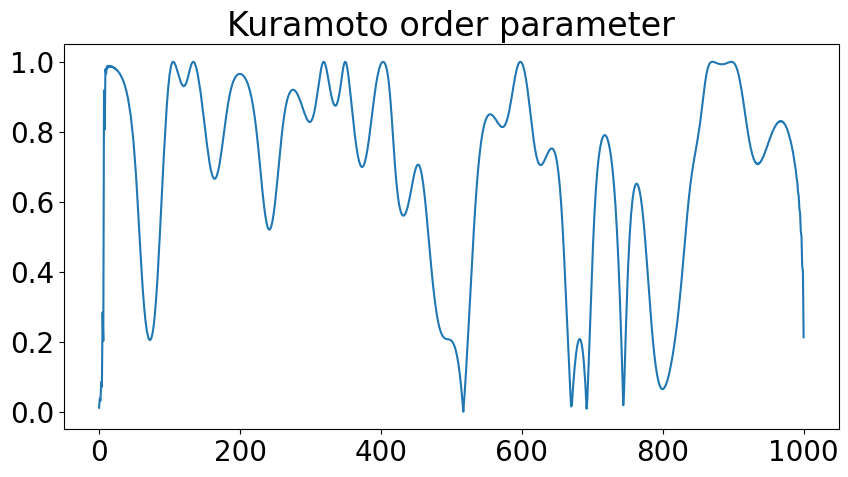

In [28]:
fig,ax = plt.subplots(figsize=(10,5))
plt.plot(R)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Kuramoto order parameter', fontsize=24)

### State space diagrams and phases plots

Text(0.5, 1.0, 'State space for phases')

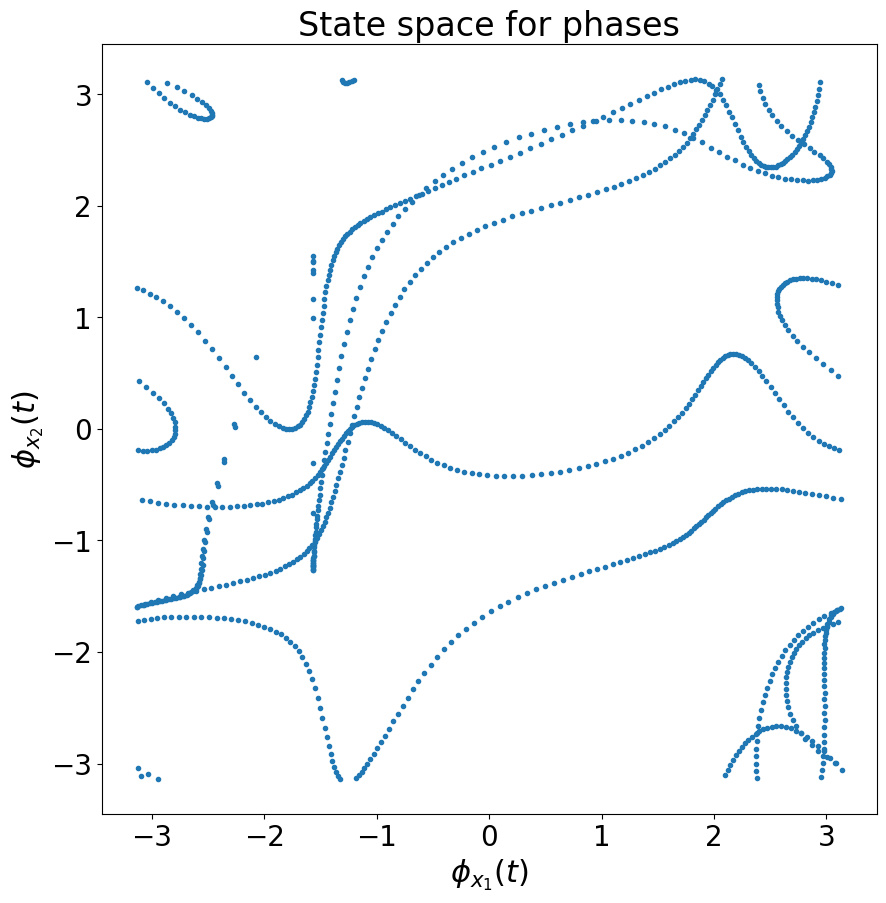

In [29]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(ph_evol_A,ph_evol_B,'.')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('$\phi_{x_1} (t)$', fontsize=22)
plt.ylabel('$\phi_{x_2} (t)$', fontsize=22)
plt.title('State space for phases', fontsize=24)

In [30]:
theta = np.linspace(-np.pi, np.pi, 100)

Text(0.5, 1.0, 'Phases')

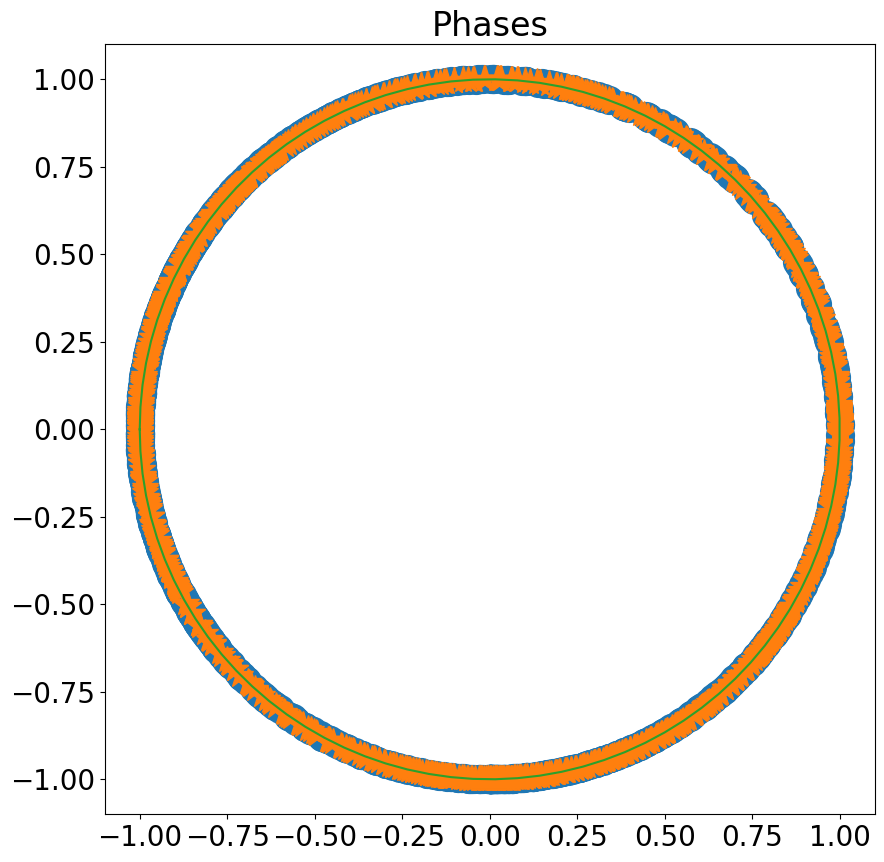

In [31]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(np.cos(ph_evol_A),np.sin(ph_evol_A),'o',np.cos(ph_evol_B),np.sin(ph_evol_B),'*',np.cos(theta), np.sin(theta), '-', markersize=20)
ax.set_aspect(1)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Phases', fontsize=24)
#plt.savefig('figures/phases.pdf')


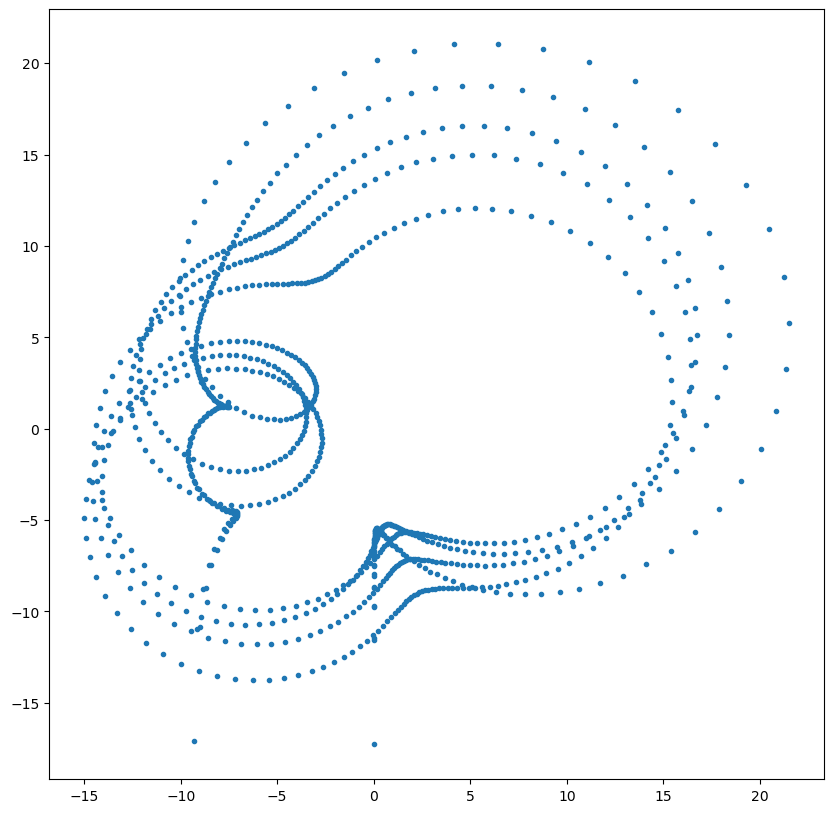

In [32]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(hil_evol_A.real,hil_evol_A.imag,'.')
#ax.set_aspect(1)

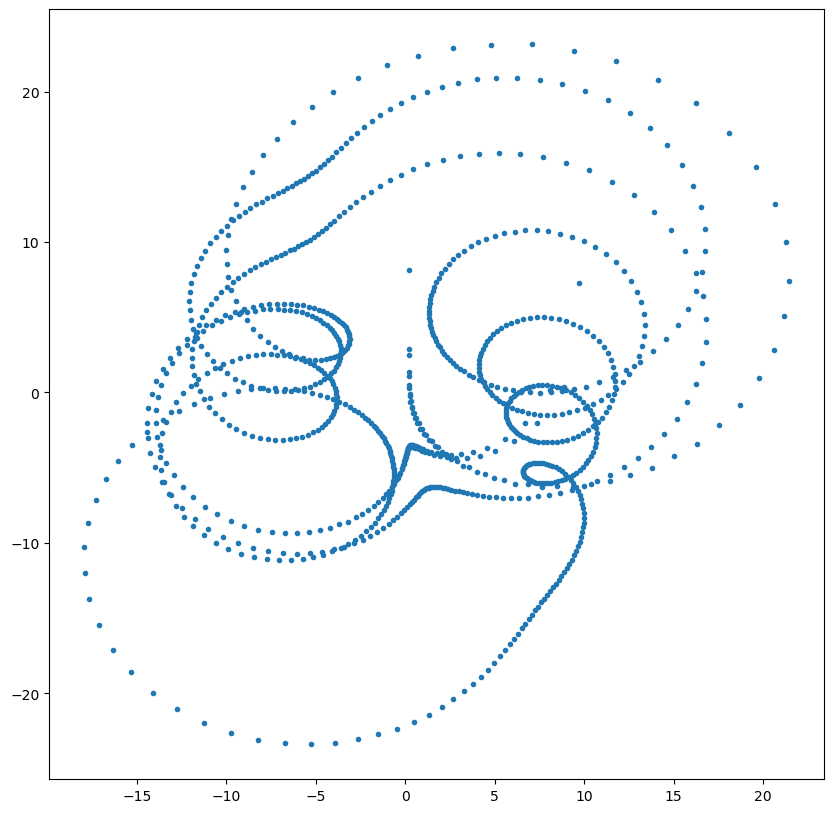

In [33]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(hil_evol_B.real,hil_evol_B.imag,'.')
#ax.set_aspect(1)

In [34]:
phA_B=np.arctan2(hil_evol_A.imag*hil_evol_B.real-hil_evol_A.real*hil_evol_B.imag, hil_evol_A.real*hil_evol_B.real+hil_evol_A.imag*hil_evol_B.imag)
phA_B

array([-3.11644993, -3.06375451, -3.07582396, ..., -2.28375971,
       -2.31005577, -2.71086   ])

Text(0.5, 1.0, 'Phase difference')

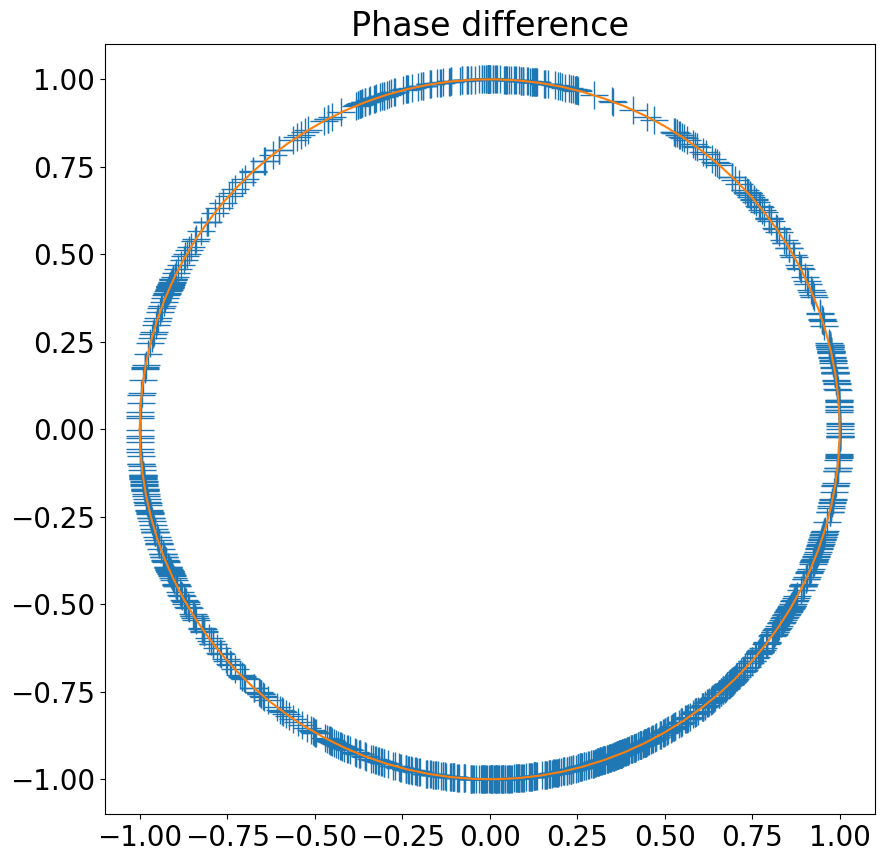

In [35]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(np.cos(phA_B),np.sin(phA_B),'+',np.cos(theta), np.sin(theta), '-', markersize=20)
ax.set_aspect(1)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Phase difference', fontsize=24)
#plt.savefig('figures/phases_diff_circ.pdf')

Text(0.5, 1.0, 'Phase difference')

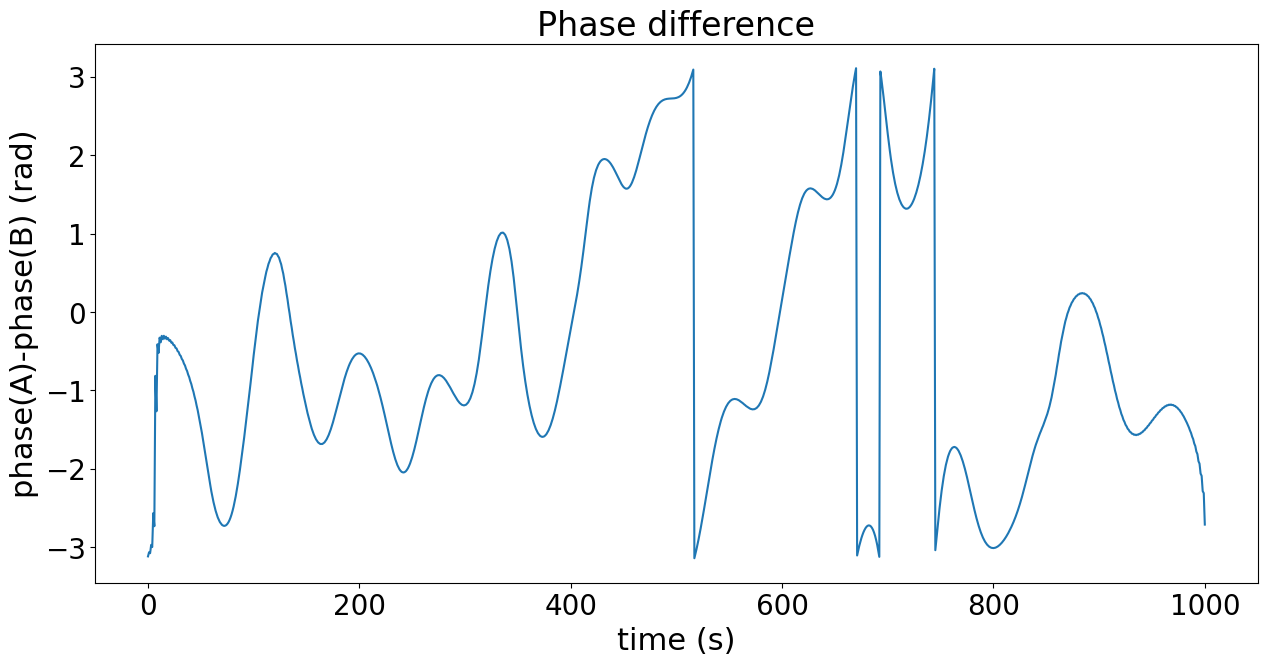

In [36]:
fig,ax = plt.subplots(figsize=(15,7))
plt.plot(df1.index,(phA_B), '-', markersize=20)
#plt.ylim([-0.2,0.2])
plt.xlabel('time (s)', fontsize=22)
plt.ylabel('phase(A)-phase(B) (rad)', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Phase difference', fontsize=24)
#plt.savefig('figures/phases_diff.pdf')

### Recurrence plot

In [41]:
def recurrence_plot(data, threshold=0.1):
    """
    Recurrence plot from a time series
    
    :param data: Time series data
    :param threshold: Threshold to determine recurrence
    :return: Recurrence plot
    """
    # Calculate the distance matrix
    N = len(data)
    distance_matrix = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            distance_matrix[i,j] = np.abs(data[i] - data[j])
            
    # Create the recurrence plot
    recurrence_plot = np.where(distance_matrix <= threshold, 1, 0)
    
    return recurrence_plot

<function matplotlib.pyplot.show(close=None, block=None)>

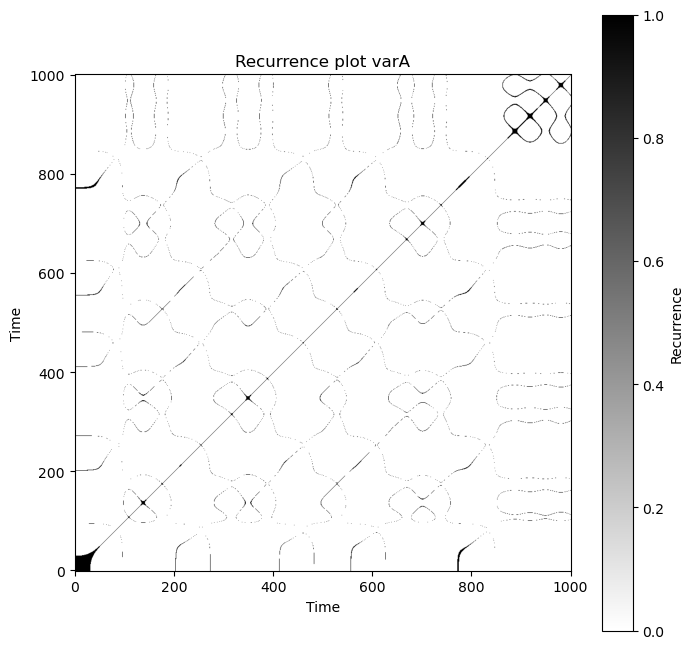

In [42]:
recA = recurrence_plot(varA, threshold=0.1)

plt.figure(figsize=(8, 8))
plt.imshow(recA, cmap='binary', origin='lower')
plt.title('Recurrence plot varA')
plt.xlabel('Time')
plt.ylabel('Time')
plt.colorbar(label='Recurrence')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

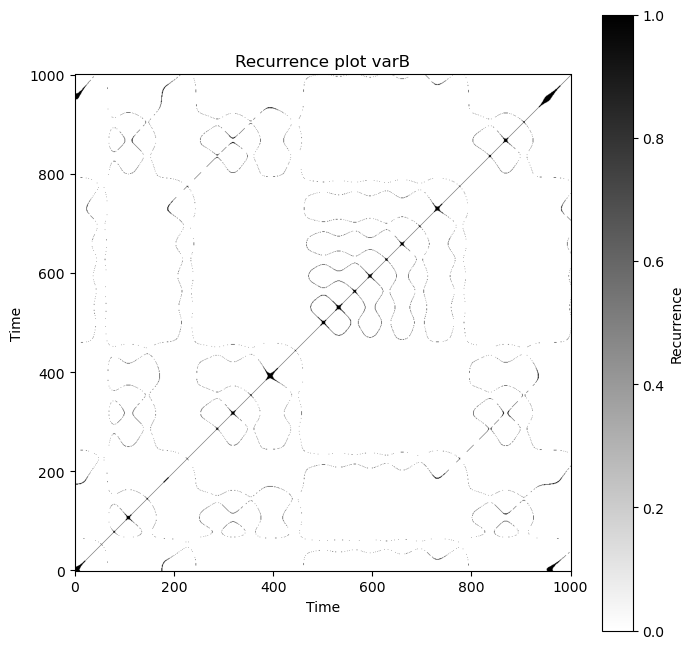

In [43]:
recB = recurrence_plot(varB, threshold=0.1)

plt.figure(figsize=(8, 8))
plt.imshow(recB, cmap='binary', origin='lower')
plt.title('Recurrence plot varB')
plt.xlabel('Time')
plt.ylabel('Time')
plt.colorbar(label='Recurrence')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

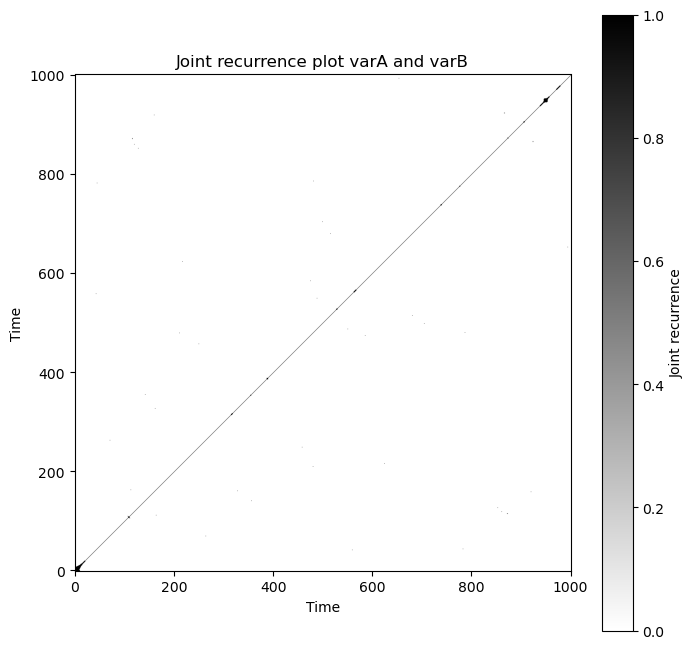

In [44]:
joint_rec = recA*recB

plt.figure(figsize=(8, 8))
plt.imshow(joint_rec, cmap='binary', origin='lower')
plt.title('Joint recurrence plot varA and varB')
plt.xlabel('Time')
plt.ylabel('Time')
plt.colorbar(label='Joint recurrence')
plt.show